# MobileNetV2 – Classificação CPRE (v6)

**Problema identificado:** O MobileNetV2 foi pré-treinado com imagens RGB normalizadas com ImageNet stats. Nas versões anteriores, as imagens grayscale eram repetidas 3x (`repeat_if_needed`) e normalizadas com `NormalizeIntensity` do MONAI — valores muito diferentes do esperado pelo modelo.

**Correção v6:**
- Carregamento das imagens diretamente como **RGB** com PIL
- Normalização com **ImageNet stats** (mean/std que o MobileNetV2 espera)
- Transforms com **torchvision** (sem MONAI) — mais compatível com imagens RGB
- Base estável do **v4** (CLAHE offline, class weights suavizados, fine-tuning faseado)

In [43]:
!pip install -q torchmetrics opencv-python-headless tqdm

In [44]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    raise RuntimeError('GPU não encontrada! Ativa em Settings > Accelerator > GPU T4 x2')

Dispositivo: cuda
GPU: Tesla T4


In [45]:
import os, cv2
from tqdm import tqdm

INPUT_DIR  = '/kaggle/input/datasets/filipapereira30/dataset-2/MIQR-CC-Dataset/training/dataset'
OUTPUT_DIR = '/kaggle/working/dataset_clahe'

if os.path.exists(OUTPUT_DIR) and any(os.scandir(OUTPUT_DIR)):
    print(f'dataset_clahe já existe — a saltar.')
else:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    for split in ['train', 'val', 'test']:
        for cls in os.listdir(os.path.join(INPUT_DIR, split)):
            in_dir  = os.path.join(INPUT_DIR,  split, cls)
            out_dir = os.path.join(OUTPUT_DIR, split, cls)
            os.makedirs(out_dir, exist_ok=True)
            print(f'Processing {split}/{cls}...')
            for fname in tqdm(os.listdir(in_dir)):
                img = cv2.imread(os.path.join(in_dir, fname), cv2.IMREAD_GRAYSCALE)
                if img is None: continue
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
                cv2.imwrite(os.path.join(out_dir, fname), clahe.apply(img))
    print('CLAHE preprocessing completed.')

base_dir = OUTPUT_DIR
print(f'base_dir = {base_dir}')

dataset_clahe já existe — a saltar.
base_dir = /kaggle/working/dataset_clahe


In [46]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random, time, warnings
warnings.filterwarnings('ignore')

from PIL import Image
from pathlib import Path
from datetime import datetime

from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, f1_score,
                              roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchmetrics.classification import MulticlassF1Score

print('Imports OK')

Imports OK


In [47]:
model_path = '/kaggle/working/MIA_AP_my_models'
os.makedirs(model_path, exist_ok=True)

def get_versioned_model_name(base_path):
    base = Path(base_path)
    ts   = datetime.now().strftime('%Y%m%d_%H%M%S')
    return str(base.parent / f'{base.stem}_{ts}{base.suffix}')

IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS_P1  = 15
EPOCHS_P2  = 60
LR_P1      = 1e-3
LR_P2      = 5e-5
PATIENCE   = 15
SEED       = 42
CW_POWER   = 0.5

# ImageNet stats – o que o MobileNetV2 espera
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print('Config OK | RGB + ImageNet normalization')

Config OK | RGB + ImageNet normalization


In [48]:
phases = ['train', 'val', 'test']
data   = {phase: {'images': [], 'labels': []} for phase in phases}

class_names = sorted([
    x for x in os.listdir(os.path.join(base_dir, 'train'))
    if os.path.isdir(os.path.join(base_dir, 'train', x))
])
num_class = len(class_names)
print(f'Classes ({num_class}): {class_names}')

valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
for phase in phases:
    for i, cname in enumerate(class_names):
        cdir = os.path.join(base_dir, phase, cname)
        imgs = [os.path.join(cdir, f) for f in os.listdir(cdir) if f.lower().endswith(valid_exts)]
        data[phase]['images'].extend(imgs)
        data[phase]['labels'].extend([i] * len(imgs))

for phase in phases:
    labels = data[phase]['labels']
    print(f'\n{phase.upper()} – {len(labels)} imagens')
    for i, c in enumerate(class_names):
        n = labels.count(i)
        print(f'  {c}: {n} ({100*n/len(labels):.1f}%)')

Classes (4): ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']

TRAIN – 1067 imagens
  Biliary_Leaks: 110 (10.3%)
  Lithiasis: 505 (47.3%)
  Normal: 197 (18.5%)
  Stricture: 255 (23.9%)

VAL – 234 imagens
  Biliary_Leaks: 24 (10.3%)
  Lithiasis: 98 (41.9%)
  Normal: 59 (25.2%)
  Stricture: 53 (22.6%)

TEST – 267 imagens
  Biliary_Leaks: 17 (6.4%)
  Lithiasis: 123 (46.1%)
  Normal: 43 (16.1%)
  Stricture: 84 (31.5%)


## Transforms – RGB + ImageNet normalization

**Mudança chave:** As imagens são carregadas como RGB e normalizadas com as stats do ImageNet. Isto é o que o MobileNetV2 pré-treinado espera receber.

Imagem carregada como RGB: RGB | tamanho: (512, 512)


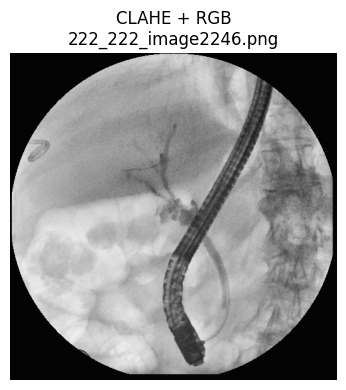

In [49]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.RandomVerticalFlip(p=0.4),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.ColorJitter(contrast=0.3, brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Visualização: confirmar que as imagens ficam RGB
sample_path = data['train']['images'][0]
img_pil = Image.open(sample_path).convert('RGB')
print(f'Imagem carregada como RGB: {img_pil.mode} | tamanho: {img_pil.size}')

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(img_pil)
ax.set_title(f'CLAHE + RGB\n{os.path.basename(sample_path)}')
ax.axis('off')
plt.tight_layout()
plt.show()

In [50]:
class ERCPDataset(Dataset):
    def __init__(self, image_files, labels, transform):
        self.image_files = image_files
        self.labels      = labels
        self.transform   = transform

    def __len__(self): return len(self.image_files)

    def __getitem__(self, idx):
        # Carrega como RGB – compatível com MobileNetV2
        img = Image.open(self.image_files[idx]).convert('RGB')
        return self.transform(img), self.labels[idx]


# Class weights suavizados
train_labels_np = np.array(data['train']['labels'])
cw_raw    = compute_class_weight('balanced', classes=np.arange(num_class), y=train_labels_np)
cw_smooth = cw_raw ** CW_POWER
cw_smooth = cw_smooth / cw_smooth.mean()
cw_tensor = torch.tensor(cw_smooth, dtype=torch.float32).to(device)

print('Class weights (suavizados):')
for i, (raw, smooth) in enumerate(zip(cw_raw, cw_smooth)):
    print(f'  {class_names[i]}: {raw:.3f} → {smooth:.3f}')

train_ds = ERCPDataset(data['train']['images'], data['train']['labels'], train_transforms)
val_ds   = ERCPDataset(data['val']['images'],   data['val']['labels'],   val_transforms)
test_ds  = ERCPDataset(data['test']['images'],  data['test']['labels'],  val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f'\nTrain: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Class weights (suavizados):
  Biliary_Leaks: 2.425 → 1.393
  Lithiasis: 0.528 → 0.650
  Normal: 1.354 → 1.041
  Stricture: 1.046 → 0.915

Train: 1067 | Val: 234 | Test: 267


In [51]:
def build_model(freeze_backbone=True):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_class)
    )
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
    return model.to(device)

model     = build_model(freeze_backbone=True)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros treináveis (fase 1): {trainable:,}')

Parâmetros treináveis (fase 1): 328,964


In [52]:
def mixup_data(x, y, alpha=0.2):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1-lam) * x[index], y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1-lam) * criterion(pred, y_b)

loss_fn = nn.CrossEntropyLoss(weight=cw_tensor, label_smoothing=0.1)
print('Loss: CrossEntropyLoss (class weights suavizados + label_smoothing=0.1)')

Loss: CrossEntropyLoss (class weights suavizados + label_smoothing=0.1)


In [53]:
def train_phase(model, train_dl, val_dl, optimizer, scheduler,
                epochs, save_path, patience, use_mixup=False, phase_name=''):

    f1_metric = MulticlassF1Score(num_classes=num_class, average='macro').to(device)
    best_f1, best_epoch, no_improve = -1.0, -1, 0
    history = {'loss': [], 'val_loss': [], 'f1': [], 'val_f1': []}

    print(f'\n{"="*55}')
    print(f' {phase_name}  |  epochs={epochs}  |  mixup={use_mixup}')
    print(f'{"="*55}')

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        y_pred_all = torch.tensor([], dtype=torch.float32, device=device)
        y_all      = torch.tensor([], dtype=torch.long,    device=device)

        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            if use_mixup:
                inputs, y_a, y_b, lam = mixup_data(inputs, labels)
                outputs = model(inputs)
                loss    = mixup_criterion(loss_fn, outputs, y_a, y_b, lam)
            else:
                outputs = model(inputs)
                loss    = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.detach() * inputs.size(0)
            y_pred_all = torch.cat([y_pred_all, outputs.detach()], dim=0)
            y_all      = torch.cat([y_all, labels], dim=0)

        epoch_loss = (running_loss / len(train_dl.dataset)).item()
        train_f1   = f1_metric(y_pred_all.argmax(dim=1), y_all).item()

        model.eval()
        val_loss = 0.0
        y_pred_v = torch.tensor([], dtype=torch.float32, device=device)
        y_v      = torch.tensor([], dtype=torch.long,    device=device)

        with torch.no_grad():
            for inputs, labels in val_dl:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs  = model(inputs)
                val_loss += loss_fn(outputs, labels).detach() * inputs.size(0)
                y_pred_v  = torch.cat([y_pred_v, outputs], dim=0)
                y_v       = torch.cat([y_v, labels],       dim=0)

        val_epoch_loss = (val_loss / len(val_dl.dataset)).item()
        val_f1         = f1_metric(y_pred_v.argmax(dim=1), y_v).item()

        history['loss'].append(epoch_loss)
        history['val_loss'].append(val_epoch_loss)
        history['f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        scheduler.step()

        print(f'Ep {epoch+1:3d}/{epochs}  loss={epoch_loss:.4f}  '
              f'val_loss={val_epoch_loss:.4f}  F1={train_f1:.4f}  val_F1={val_f1:.4f}  '
              f'LR={optimizer.param_groups[0]["lr"]:.2e}')

        if val_f1 > best_f1:
            best_f1, best_epoch = val_f1, epoch+1
            torch.save(model.state_dict(), save_path)
            print(f'  ✔ Melhor modelo guardado (val F1={best_f1:.4f})')
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f'Early stopping ep {epoch+1}. Melhor: {best_epoch}, F1={best_f1:.4f}')
            break

    # Curvas de aprendizagem
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['loss'], label='Train'); ax1.plot(history['val_loss'], label='Val')
    ax1.set_title(f'{phase_name} – Loss'); ax1.legend()
    ax2.plot(history['f1'], label='Train'); ax2.plot(history['val_f1'], label='Val')
    ax2.axhline(0.738, color='red', linestyle='--', label='Baseline')
    ax2.set_title(f'{phase_name} – F1'); ax2.legend()
    plt.tight_layout()
    plt.savefig(f'{model_path}/curves_{phase_name}.png', dpi=150)
    plt.show()

    print(f'Fase concluída – melhor val F1: {best_f1:.4f}')
    return best_f1


 Fase1_FeatureExtraction  |  epochs=15  |  mixup=False
Ep   1/15  loss=1.3999  val_loss=1.3575  F1=0.2334  val_F1=0.1465  LR=9.89e-04
  ✔ Melhor modelo guardado (val F1=0.1465)
Ep   2/15  loss=1.3651  val_loss=1.3607  F1=0.2455  val_F1=0.1468  LR=9.57e-04
  ✔ Melhor modelo guardado (val F1=0.1468)
Ep   3/15  loss=1.3469  val_loss=1.3904  F1=0.2952  val_F1=0.2161  LR=9.05e-04
  ✔ Melhor modelo guardado (val F1=0.2161)
Ep   4/15  loss=1.3297  val_loss=1.3782  F1=0.3574  val_F1=0.2489  LR=8.36e-04
  ✔ Melhor modelo guardado (val F1=0.2489)
Ep   5/15  loss=1.3012  val_loss=1.4195  F1=0.4199  val_F1=0.2269  LR=7.52e-04
Ep   6/15  loss=1.2979  val_loss=1.3926  F1=0.4160  val_F1=0.2661  LR=6.58e-04
  ✔ Melhor modelo guardado (val F1=0.2661)
Ep   7/15  loss=1.2842  val_loss=1.3517  F1=0.4200  val_F1=0.2961  LR=5.57e-04
  ✔ Melhor modelo guardado (val F1=0.2961)
Ep   8/15  loss=1.2953  val_loss=1.3479  F1=0.4089  val_F1=0.2073  LR=4.53e-04
Ep   9/15  loss=1.2750  val_loss=1.3525  F1=0.4452  va

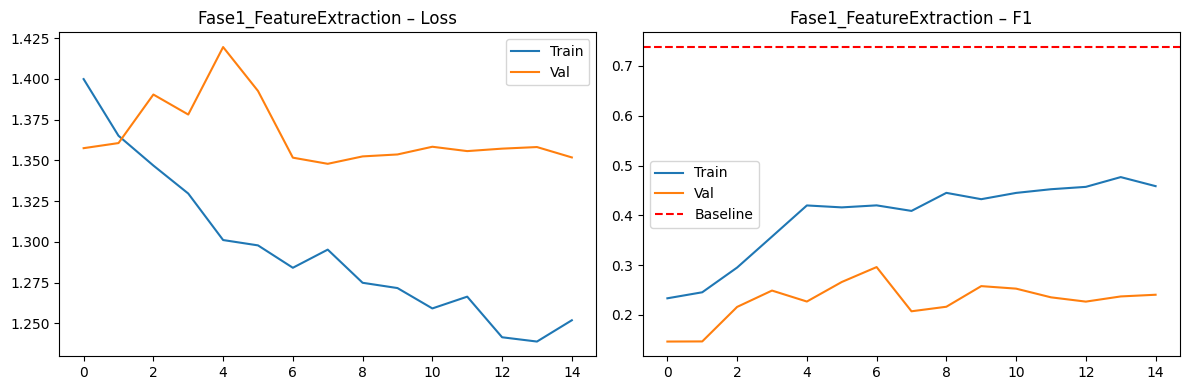

Fase concluída – melhor val F1: 0.2961
Tempo fase 1: 93.0s


In [54]:
set_seed(SEED)
model      = build_model(freeze_backbone=True)
model_name = get_versioned_model_name(f'{model_path}/mobilenet_v2_v6.pth')

opt1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_P1, weight_decay=1e-4
)
sch1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=EPOCHS_P1, eta_min=1e-5)

t0 = time.perf_counter()
train_phase(model, train_loader, val_loader,
            opt1, sch1, EPOCHS_P1, model_name,
            patience=PATIENCE, use_mixup=False,
            phase_name='Fase1_FeatureExtraction')
print(f'Tempo fase 1: {time.perf_counter()-t0:.1f}s')

Backbone descongelado: 2,552,836 parâmetros

 Fase2_FineTuning  |  epochs=60  |  mixup=True
Ep   1/60  loss=1.3020  val_loss=1.3538  F1=0.3066  val_F1=0.2553  LR=5.00e-05
  ✔ Melhor modelo guardado (val F1=0.2553)
Ep   2/60  loss=1.2830  val_loss=1.3429  F1=0.3503  val_F1=0.2749  LR=4.99e-05
  ✔ Melhor modelo guardado (val F1=0.2749)
Ep   3/60  loss=1.2774  val_loss=1.3623  F1=0.3773  val_F1=0.2662  LR=4.97e-05
Ep   4/60  loss=1.2705  val_loss=1.3585  F1=0.3799  val_F1=0.2773  LR=4.95e-05
  ✔ Melhor modelo guardado (val F1=0.2773)
Ep   5/60  loss=1.2406  val_loss=1.3472  F1=0.4104  val_F1=0.2801  LR=4.91e-05
  ✔ Melhor modelo guardado (val F1=0.2801)
Ep   6/60  loss=1.2106  val_loss=1.3476  F1=0.3670  val_F1=0.2876  LR=4.88e-05
  ✔ Melhor modelo guardado (val F1=0.2876)
Ep   7/60  loss=1.1957  val_loss=1.3588  F1=0.3603  val_F1=0.2296  LR=4.83e-05
Ep   8/60  loss=1.1681  val_loss=1.3665  F1=0.4088  val_F1=0.3004  LR=4.78e-05
  ✔ Melhor modelo guardado (val F1=0.3004)
Ep   9/60  loss=1.

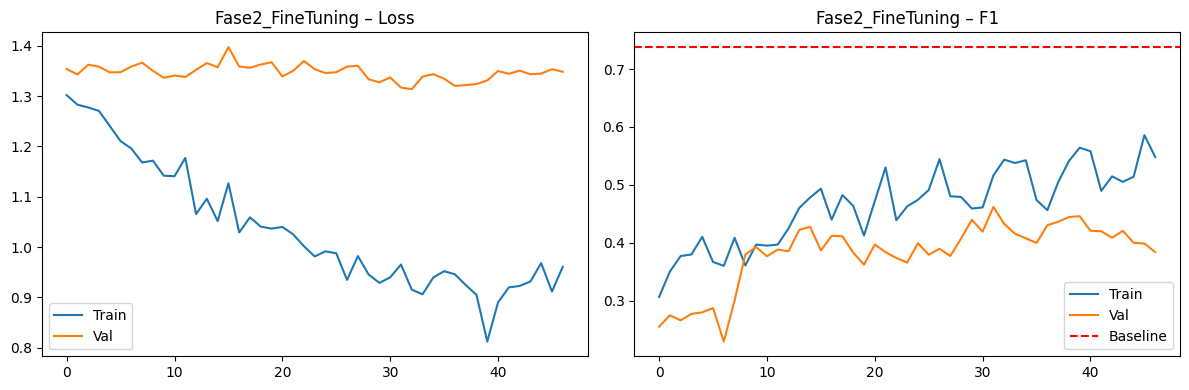

Fase concluída – melhor val F1: 0.4620
Tempo fase 2: 315.5s


In [55]:
model.load_state_dict(torch.load(model_name))
for param in model.parameters():
    param.requires_grad = True
print(f'Backbone descongelado: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} parâmetros')

opt2 = torch.optim.AdamW(model.parameters(), lr=LR_P2, weight_decay=1e-4)
sch2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EPOCHS_P2, eta_min=1e-7)

t0 = time.perf_counter()
train_phase(model, train_loader, val_loader,
            opt2, sch2, EPOCHS_P2, model_name,
            patience=PATIENCE, use_mixup=True,
            phase_name='Fase2_FineTuning')
print(f'Tempo fase 2: {time.perf_counter()-t0:.1f}s')

In [56]:
model.load_state_dict(torch.load(model_name))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs.to(device))
        probs   = F.softmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(np.argmax(probs, axis=1))
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

f1  = f1_score(all_labels, all_preds, average='macro')
acc = accuracy_score(all_labels, all_preds)

print(f'\n{"="*55}')
print(f' Accuracy  : {acc:.4f}')
print(f' F1-macro  : {f1:.4f}')
print(f' Baseline  : 0.7380')
print(f' Delta     : {f1-0.738:+.4f}')
print(f'{"="*55}\n')
print(classification_report(all_labels, all_preds,
                             target_names=class_names, digits=4, zero_division=0))


 Accuracy  : 0.6030
 F1-macro  : 0.5215
 Baseline  : 0.7380
 Delta     : -0.2165

               precision    recall  f1-score   support

Biliary_Leaks     0.4444    0.4706    0.4571        17
    Lithiasis     0.6149    0.8049    0.6972       123
       Normal     0.3824    0.3023    0.3377        43
    Stricture     0.7593    0.4881    0.5942        84

     accuracy                         0.6030       267
    macro avg     0.5502    0.5165    0.5215       267
 weighted avg     0.6120    0.6030    0.5916       267



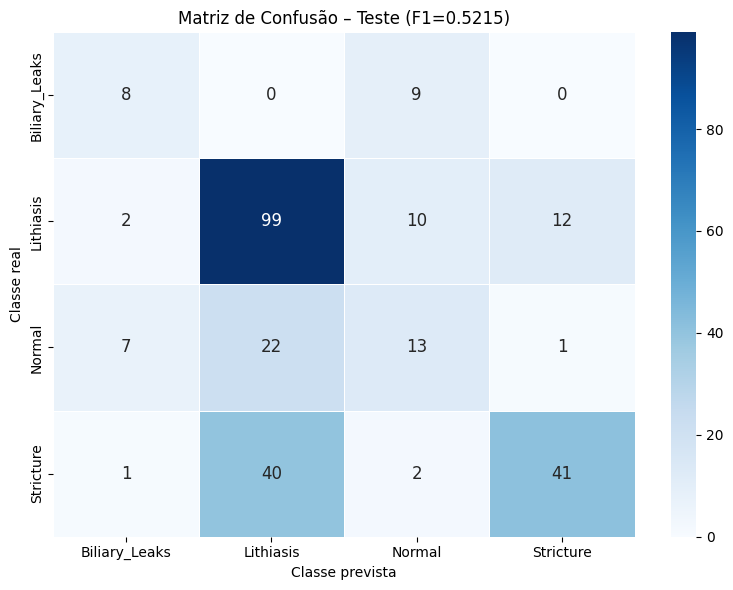

In [57]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, annot_kws={'size': 12})
plt.ylabel('Classe real'); plt.xlabel('Classe prevista')
plt.title(f'Matriz de Confusão – Teste (F1={f1:.4f})')
plt.tight_layout()
plt.savefig(f'{model_path}/confusion_matrix.png', dpi=200)
plt.show()

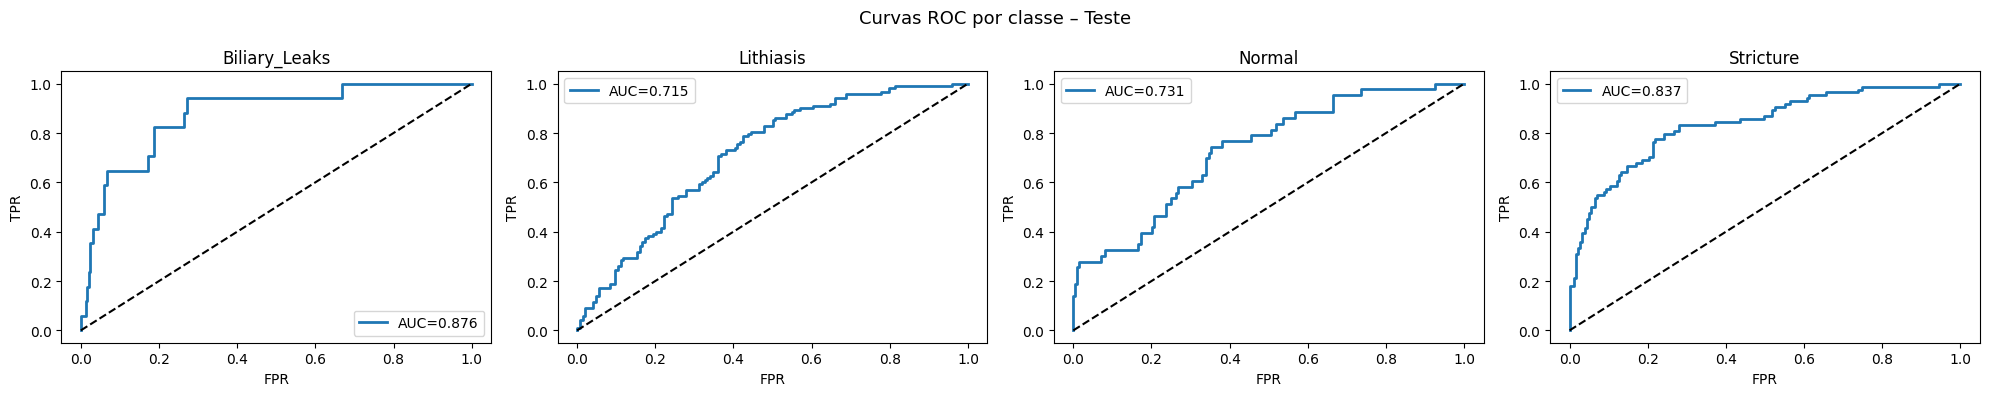

AUC-ROC macro (OvR): 0.7898


In [58]:
y_bin = label_binarize(all_labels, classes=np.arange(num_class))
fig, axes = plt.subplots(1, num_class, figsize=(5*num_class, 4))
for i, (ax, cname) in enumerate(zip(axes, class_names)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_val = roc_auc_score(y_bin[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, lw=2, label=f'AUC={auc_val:.3f}')
    ax.plot([0,1],[0,1],'k--'); ax.set_title(cname)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend()
plt.suptitle('Curvas ROC por classe – Teste', fontsize=13)
plt.tight_layout()
plt.savefig(f'{model_path}/roc_curves.png', dpi=150)
plt.show()
mean_auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')
print(f'AUC-ROC macro (OvR): {mean_auc:.4f}')

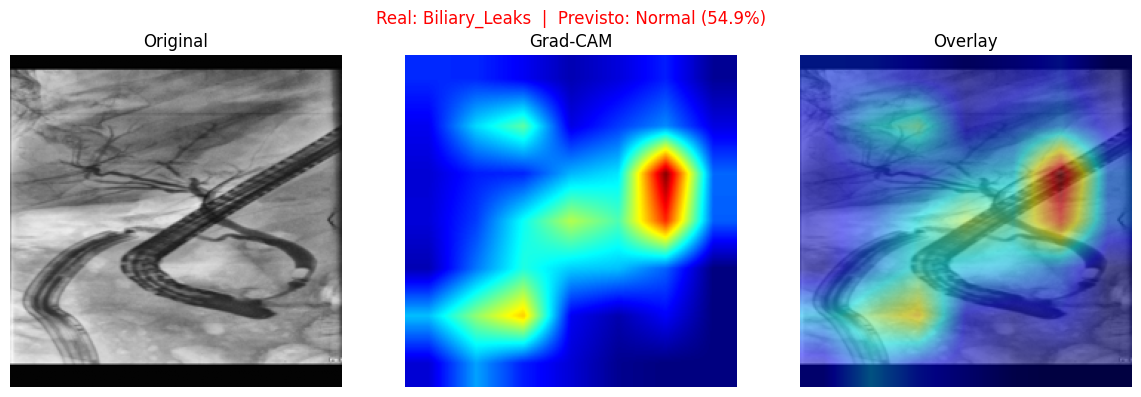

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Biliary_Leaks_0.png


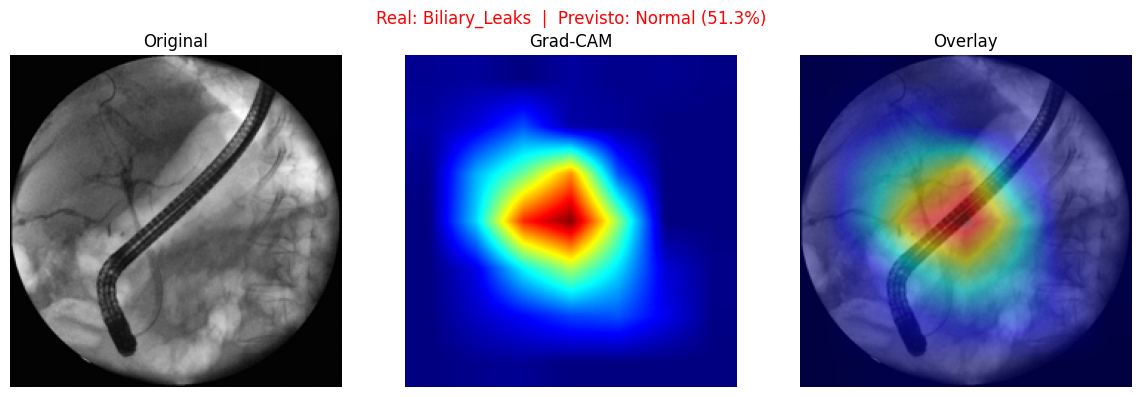

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Biliary_Leaks_1.png


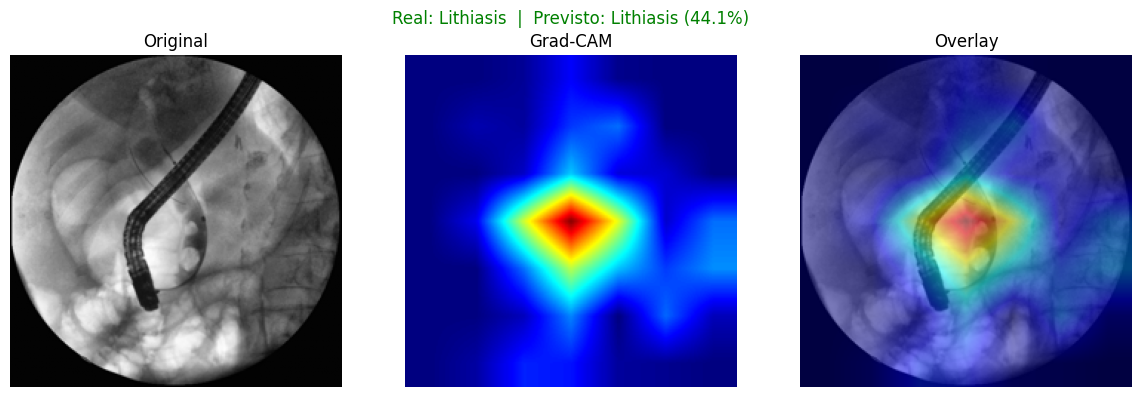

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Lithiasis_0.png


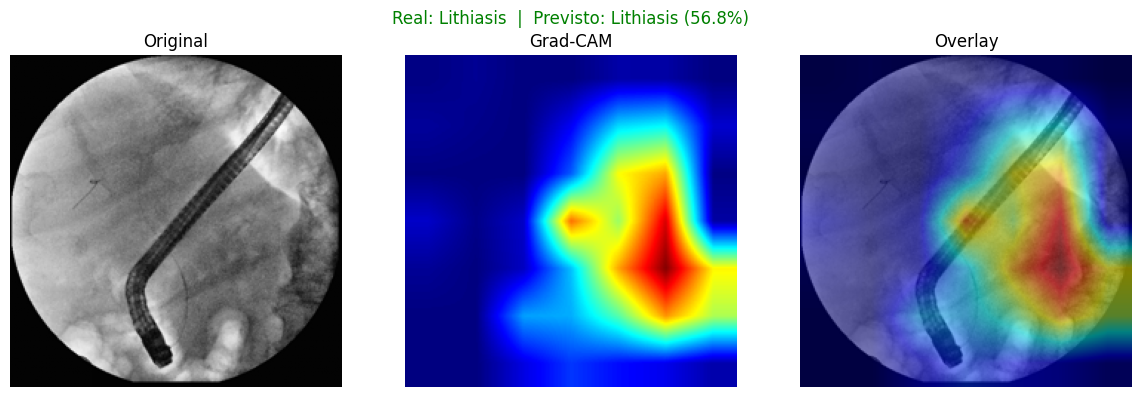

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Lithiasis_1.png


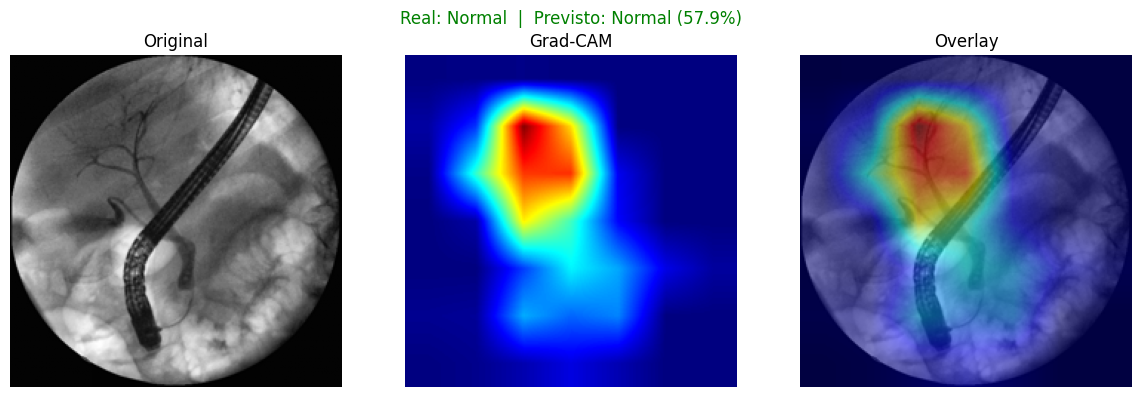

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Normal_0.png


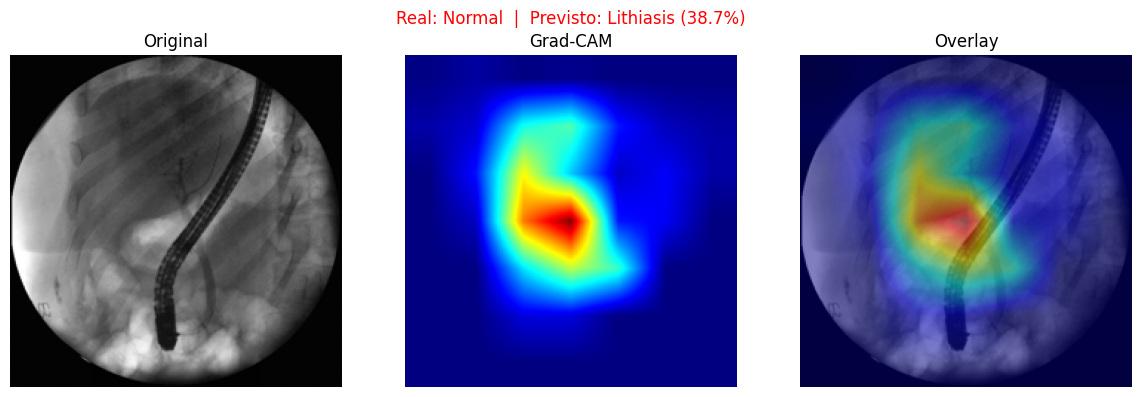

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Normal_1.png


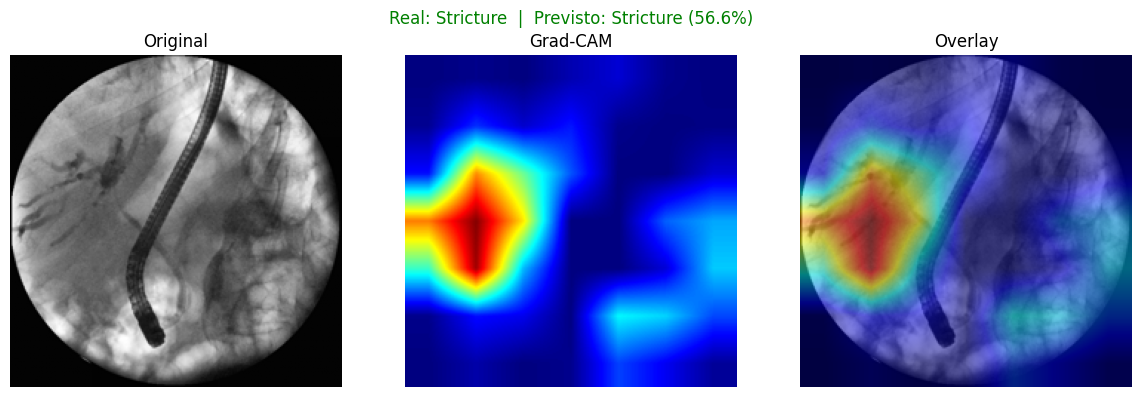

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Stricture_0.png


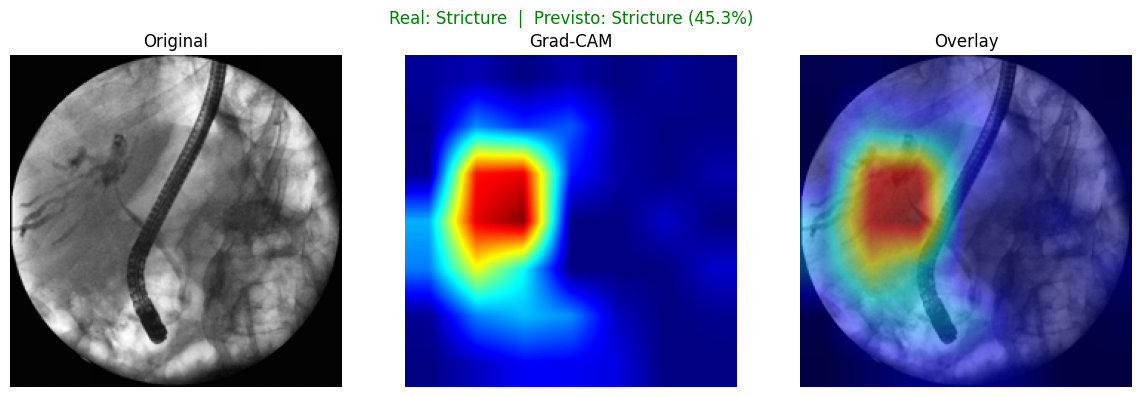

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Stricture_1.png


In [59]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        x   = input_tensor.unsqueeze(0).to(device).requires_grad_(True)
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()
        self.model.zero_grad()
        oh = torch.zeros_like(out); oh[0, class_idx] = 1.0
        out.backward(gradient=oh)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, class_idx, F.softmax(out, dim=1)[0, class_idx].item()

gradcam = GradCAM(model, target_layer=model.features[-1])

def show_gradcam(img_path, true_label, save_path=None):
    img_pil    = Image.open(img_path).convert('RGB')
    img_tensor = val_transforms(img_pil)
    cam, pred_idx, prob = gradcam.generate(img_tensor)

    raw     = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE)).convert('L'))
    raw_rgb = cv2.cvtColor(raw, cv2.COLOR_GRAY2RGB)
    cam_r   = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap((cam_r*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.5*raw_rgb + 0.5*heatmap).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(raw, cmap='gray'); axes[0].set_title('Original');  axes[0].axis('off')
    axes[1].imshow(heatmap);          axes[1].set_title('Grad-CAM');  axes[1].axis('off')
    axes[2].imshow(overlay);          axes[2].set_title('Overlay');   axes[2].axis('off')
    cor = 'green' if pred_idx == true_label else 'red'
    plt.suptitle(f'Real: {class_names[true_label]}  |  Previsto: {class_names[pred_idx]} ({prob:.1%})',
                 fontsize=12, color=cor)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=200)
    plt.show()

os.makedirs(f'{model_path}/gradcam', exist_ok=True)
for ci, cname in enumerate(class_names):
    imgs = [(p,l) for p,l in zip(data['test']['images'], data['test']['labels']) if l == ci]
    for k, (path, lbl) in enumerate(imgs[:2]):
        save_file = f'{model_path}/gradcam/gradcam_{cname}_{k}.png'
        show_gradcam(path, lbl, save_path=save_file)
        print(f'Guardado: {save_file}')

In [60]:
print('='*60)
print('RESUMO COMPARATIVO')
print('='*60)
print(f'  v0 (professor, CPU)     test F1 = 0.4564')
print(f'  v1 (CPU)                test F1 = 0.4973')
print(f'  v2 (GPU, colapso)       test F1 = 0.3063')
print(f'  v3 (GPU)                test F1 = 0.4771')
print(f'  v4 (CLAHE offline)      test F1 = 0.5558')
print(f'  v5 (FocalLoss+gradual)  test F1 = 0.4112')
print(f'  v6 (RGB+ImageNet norm)  test F1 = {f1:.4f}')
print(f'  Baseline artigo                 = 0.7380')
print(f'  Delta vs baseline               = {f1-0.738:+.4f}')
print('='*60)

RESUMO COMPARATIVO
  v0 (professor, CPU)     test F1 = 0.4564
  v1 (CPU)                test F1 = 0.4973
  v2 (GPU, colapso)       test F1 = 0.3063
  v3 (GPU)                test F1 = 0.4771
  v4 (CLAHE offline)      test F1 = 0.5558
  v5 (FocalLoss+gradual)  test F1 = 0.4112
  v6 (RGB+ImageNet norm)  test F1 = 0.5215
  Baseline artigo                 = 0.7380
  Delta vs baseline               = -0.2165
